# **UNet18** - Performance of the Different Implementations Variants

In this notebook we display results that we got from the the ```UNet18``` Model's different variants.

---

The results are shown for different versions of the Implementation:

**MAYO Data set:**

*   M5 - Basic UNet18 trained and tested on ```MAYO``` dataset
*   M6 - Tailored UNet18 fine-tuned encoder ```ResNet18``` with ```ImageNet```, trained and tested on ```MAYO``` dataset

**MAR Data set:**

*   M7 - Tailored UNet18 fine-tuned encoder ```ResNet18``` with ```ImageNet```, trained and tested on ```MAR``` dataset
*   M8 - Tailored UNet18 complete fine-tuned with M6, trained and tested on ```MAR``` dataset
* M9 - Tailored UNet18 complete fine-tuned with M6, trained and tested on ```MAR``` dataset with optuna optimizing learning rate.
*   M10 - Tailored UNet18 complete fine-tuned with M6, trained and tested on ```MAR``` dataset with optuna optimizing learning rate with cosine scheduler.
*   M11 - Tailored UNet18 complete fine-tuned with M6, trained and tested on ```MAR``` dataset with optuna optimizing learning rate with augmentation.


---

**Implementation Information:**

Size: 54.67 MB

Number of trainable weights:  14,319,873


---
Images display format:

**Input** (quarter-dosed (QD) / metal artifacts corrupted image)   **||**   **Net** output image **||**  **GT** (full-dosed (FD) / clean) image

### **M5** | Basic UNet18 trained and tested on ```MAYO``` dataset
In the begining, we took the Resnet18 model ,with the weights initialized with Kaiming (He) Uniform, as our encoder. We build a custom decoder to fit our Resnet18 encoders dimmension using a U-Net architecture.

Training time: ~1 hour.

Here we show, for training + testing on MAYO dataset:


1.   Net Performance on test set (patient L506 - 8% of all data set)
2.   Losses plots (validition patient L109 - 5% of all data set)
---
As one can see, the output images which are produced by the deep net, **have much worse quality even from the input quater dose images** (in terms of RMSE, SSIM, and PSNR).
However, the losses graph seem to have some bumps on the validition set - so a scheduler for the learning rate should be considered (as seen in M10).

---

Source code from: ```Basic_UNet18_M5.ipynb```


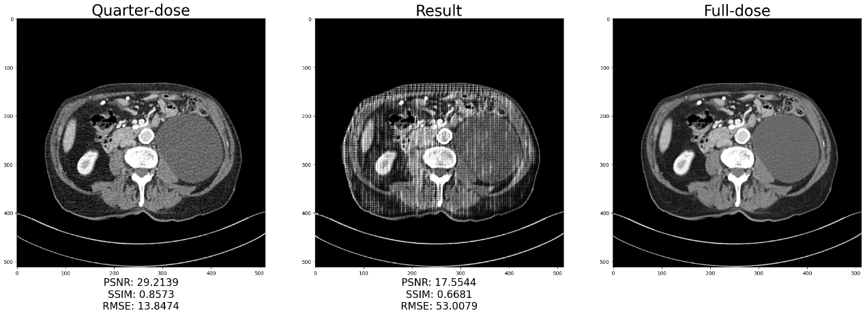

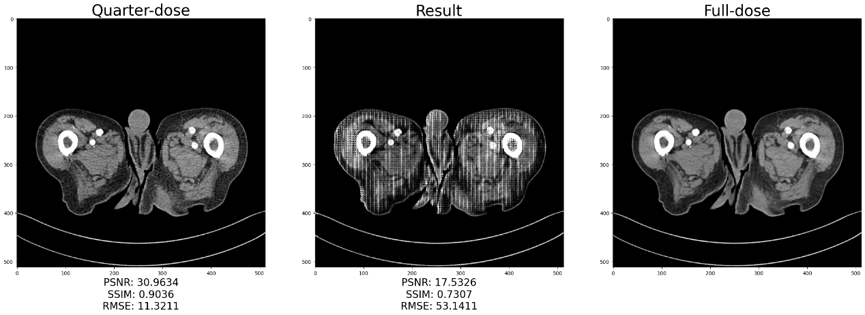

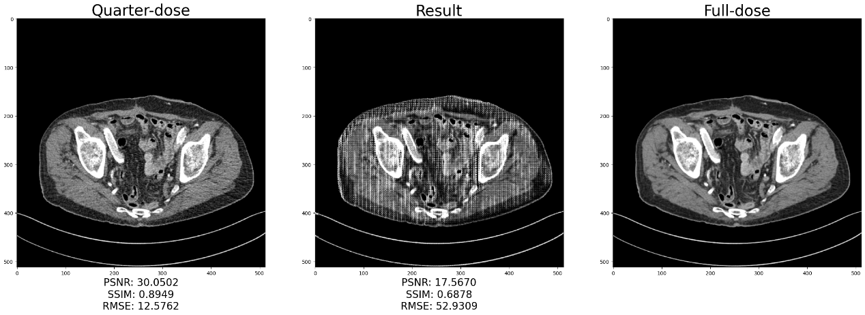

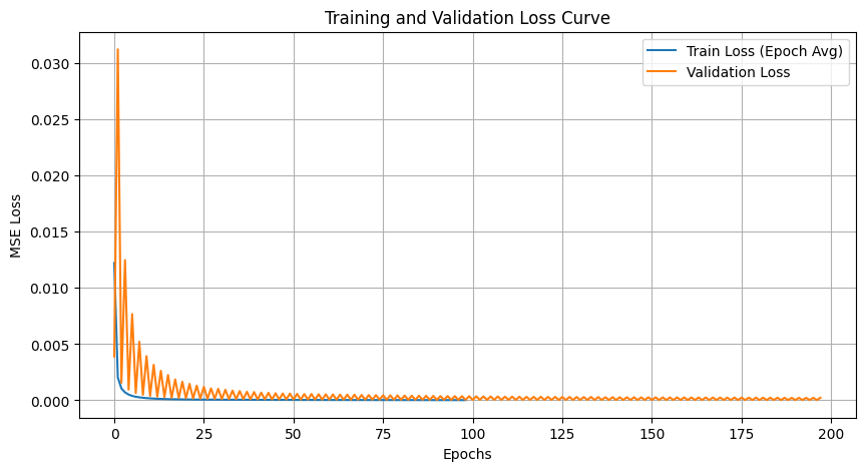

### **M6** | Tailored UNet18 fine-tuned encoder ```ResNet18``` with ```ImageNet```, trained and tested on ```MAYO``` dataset

In order to improve preformence on the dataset, in this part we display some results that were recieved from the Tailored UNet18 model we created on the test set (test patient L506).

The following changes were applied to the Basic UNet18 model: Transfer learning - initializing with pre-trained ResNet18 weights for the encoder, bigger patches, different learning rates for the encoder and the decoder, a 5 epochs warm-up and the model rans over 37 epochs instead of 100 epochs due to maximum Google Colab free runtime and memory limits.

Training time: ~3 hours.

Here we show, for training + testing on MAR dataset:
1.   Net Performance on test set (8% taken equaly from every body data folder)
2.   Losses plots (validition was 5% taken equaly from every body data folder)
---

As one can see, the output images which are produced by the deep net, **have some better quality from the input quater dose images and better quality then the Basic UNet18 Model** (in terms of RMSE, SSIM, and PSNR). In addition the losses graph is even noiser than before, yet we got better results.

---

Source code from: ```Tailored_UNet18_MAYO_M6.ipynb```


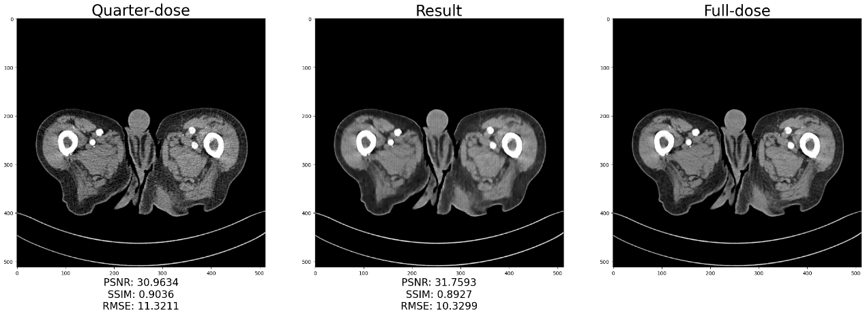

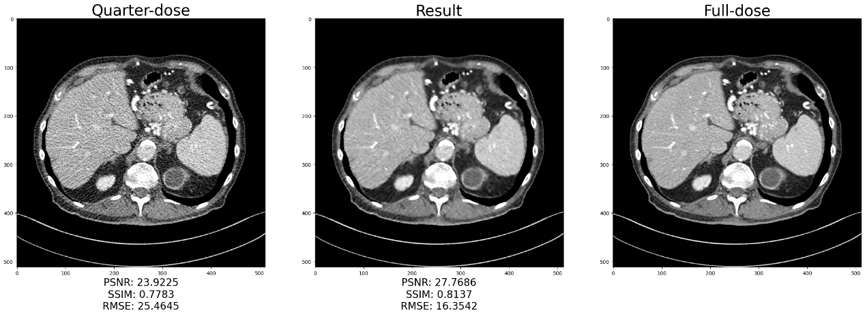

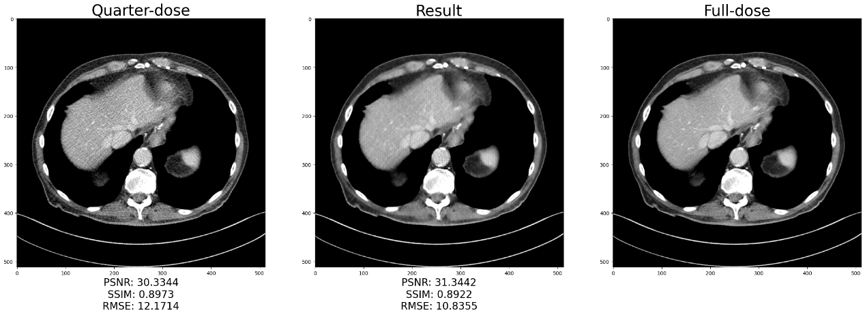

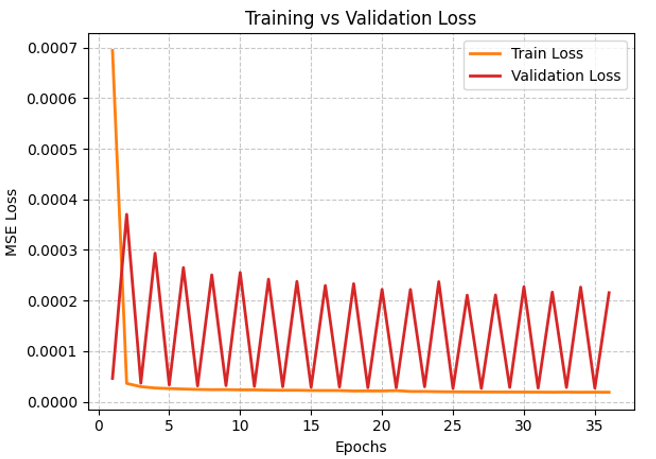



### **Generaliztaion Check** | M6 model tested on  ```MAR``` dataset
Next, we examined the performance of the UNet18 model M6 on the other data set - Metal Artifacts Removal (```MAR```).

Using the M6 model, we initialized the net weigths to the 4000-iterations model that we get from ```MAYO``` (the most updated model of the mentioned training) and tested its preformence on the ```MAR``` test set.

Here we show, for testing on ```MAR``` dataset:

*  Net Performance on test set (8% taken equaly from every body data folder)

---
It can be seen that the output images which are produced by the deep net, **have slightly better quality compared with the input images** (mainly in terms of RMSE and PSNR). However, the metal artifacts are still there as can be seen quite clearly in the net output.

---

Source code from: ```Tailored_UNet18_MAR_M7_to_M11.ipynb``` (using test mode).


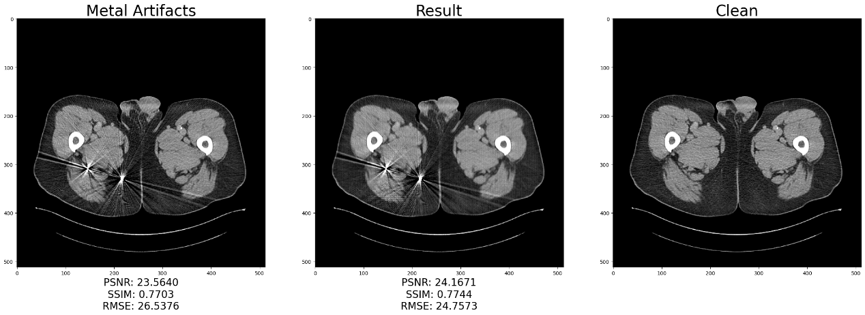

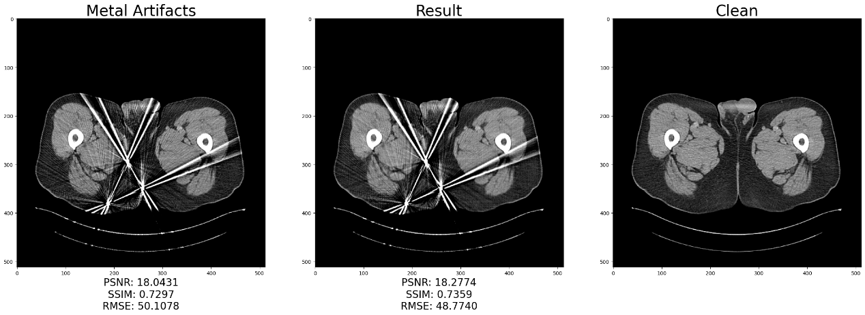

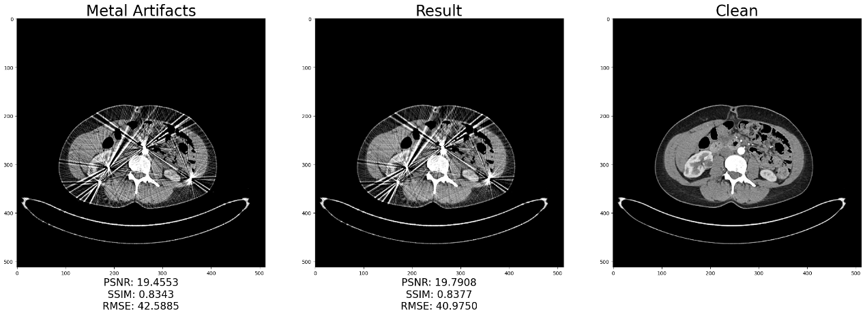

### **M7** | Tailored UNet18 fine-tuned encoder ```ResNet18``` with ```ImageNet```, trained and tested on ```MAR``` dataset


We want to compare between the preformence of different fine-tunning of the encoder, ```ImageNet``` initialization and the ```MAYO``` initialization from the M6 model.

In this part we show the preformence of initializing the encoder's weights with ```ImageNet``` weights than training and testing on ```MAR``` dataset.


Training time: ~3 hours.

Here we show, for training + testing on MAR dataset :
1.   Net Performance on test set (8% taken equaly from every body data folder)
2.   Losses plots (validition was 5% taken equaly from every body data folder)

---

As one can see, the output images which are produced by the deep net,  **have better quality compared to the input images** (mainly in terms of RMSE and PSNR). However, some of the metal artifacts can still be seen in the net output, and also a blur can be clearly spotted but less than the previous section of model M6 preformence.

---
Source code from: ```Tailored_UNet18_MAR_M7_to_M11.ipynb``` (using train mode).

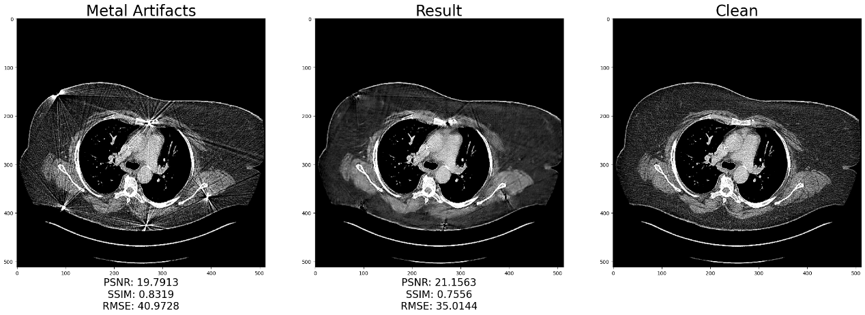

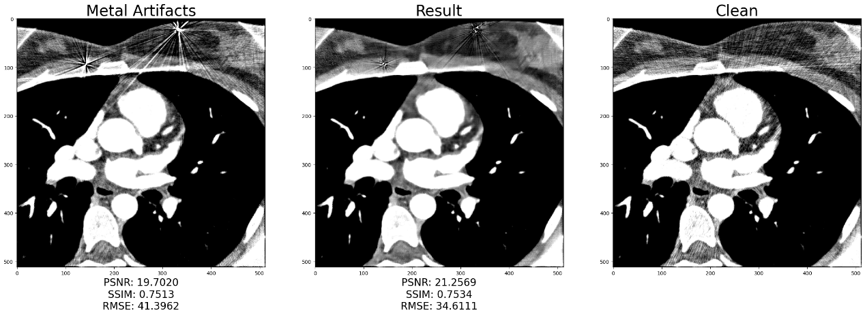

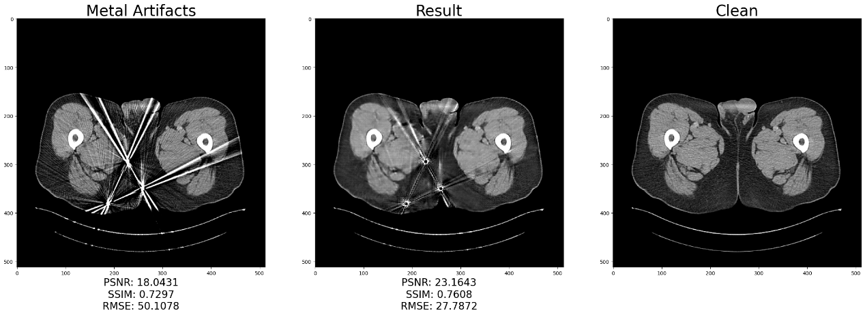

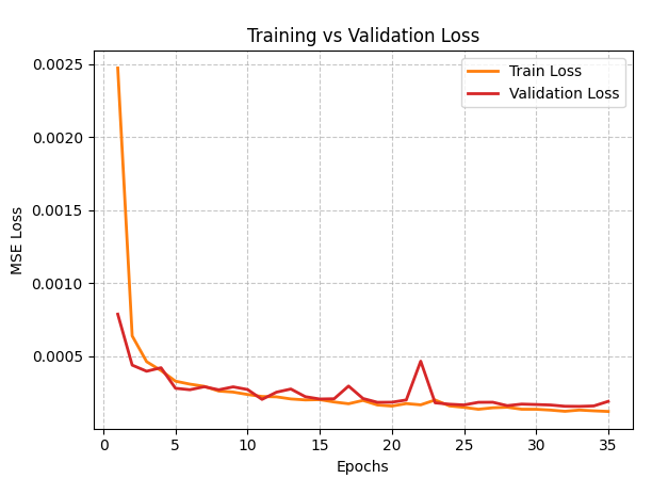

### **M8** | Tailored UNet18 fine-tuned with M6, trained and tested on ```MAR``` dataset

In this part we show the preformence of initializing the encoder's weights with ```MAYO``` weights than training and testing on ```MAR``` dataset.

---
Training time: ~3 hours.

Here we show, for training + testing on MAR dataset :
1.   Net Performance on test set (8% taken equaly from every body data folder)
2.   Losses plots (validition was 5% taken equaly from every body data folder)

---

As one can see, the output images which are produced by the deep net,  **have better quality compared to the input images** (mainly in terms of RMSE and PSNR). However, the model covered the artifacts in black and blurred the rest of the picture. This is a known problem using MSE as a loss function for the deep net, MSE will give a lower score for black pixels than shiffted gray pixels score.

---
Source code from: ```Tailored_UNet18_MAR_M7_to_M11.ipynb``` (using train_fine_tune mode with M6 saved model from 4000 iterations).

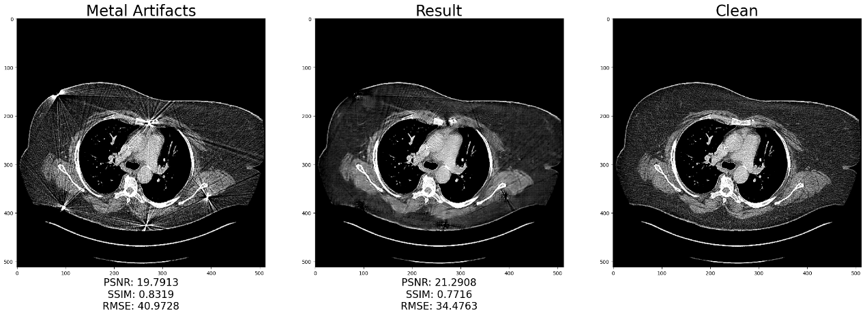

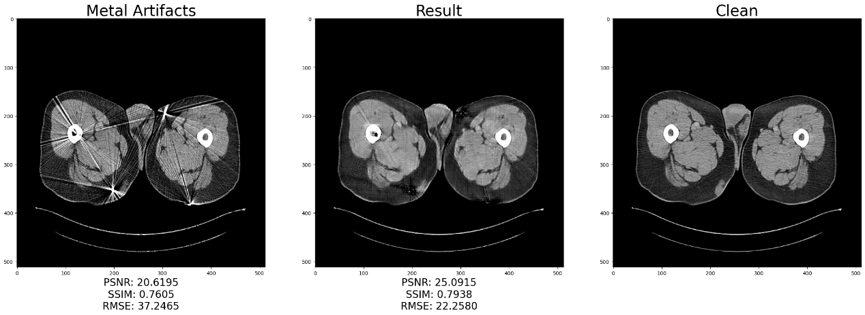

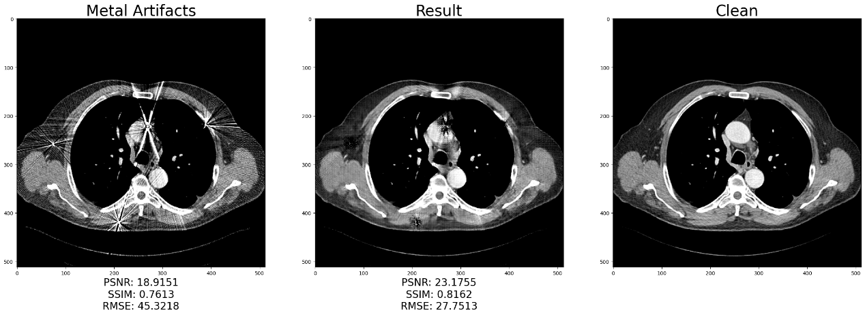

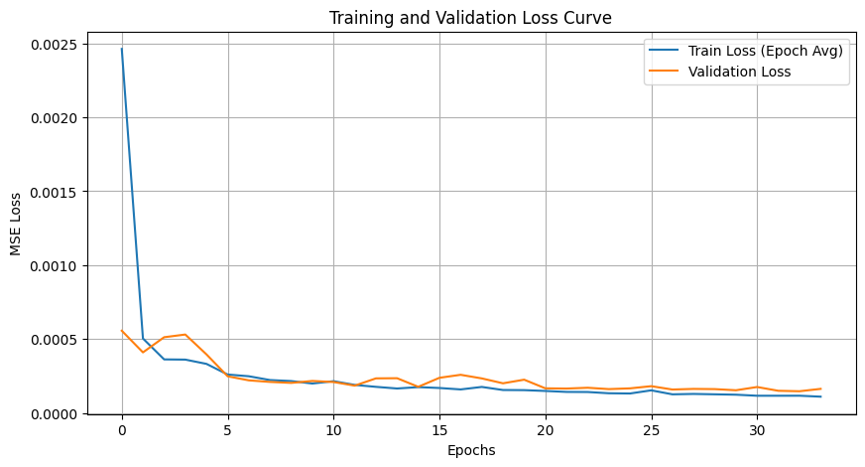

### **M9** | Tailored UNet18 fine-tuned with M6, trained and tested on ```MAR``` dataset with ```Optuna``` optimizing learning rates

Next, we will compare the preformence of using optimal ```Optuna``` learning rates to the the previous learning rates in M8. First, we ran ```Optuna``` for finding the optimal learning rates, than we trained the model like before with M8, initializing the encoder's weights with ```MAYO``` weights training and testing on ```MAR``` dataset with Optuna learning rates.

---
Running ```Optuna```: ~2 hours.
Training time: ~3 hours.

Here we show, for training + testing on MAR dataset :
1.   Net Performance on test set (8% taken equaly from every body data folder)
2.   Losses plots (validition was 5% taken equaly from every body data folder)

---

As one can see, the output images which are produced by the deep net,  **have better quality compared to the input images**,in terms of RMSE and PSNR, and **somewhat similar visual results compare to M8**. Still, some of the metal artifacts are still noticble a bit more than M8.

---
Source code from: ```Tailored_UNet18_MAR_M7_to_M11.ipynb``` (using optuna mode and later train_fine_tune mode with M6 saved model from 4000 iterations).

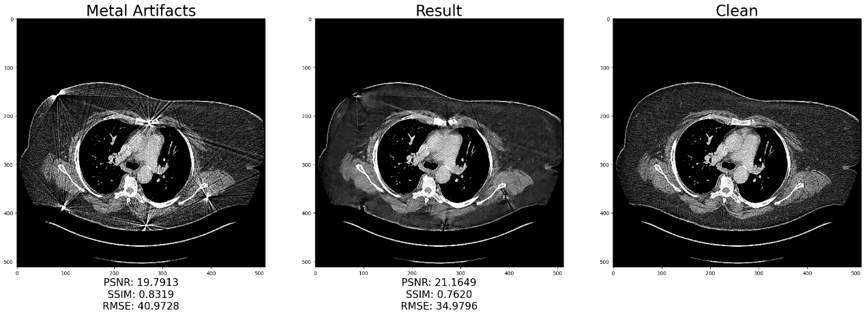

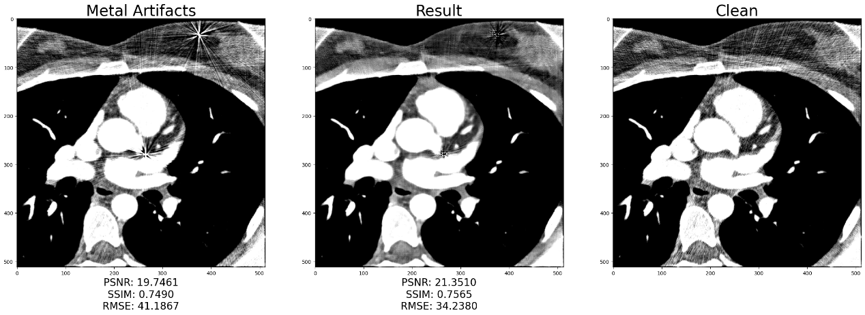

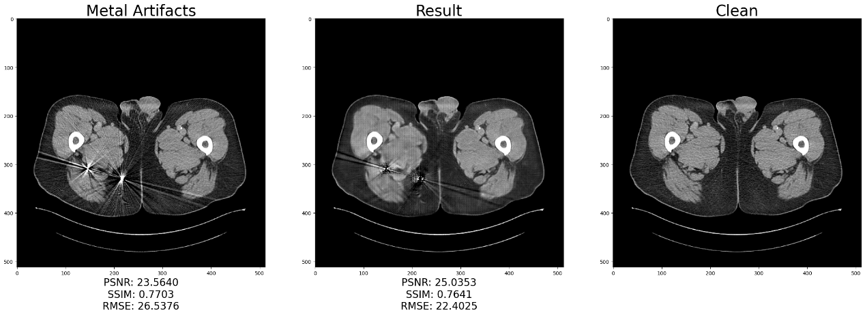

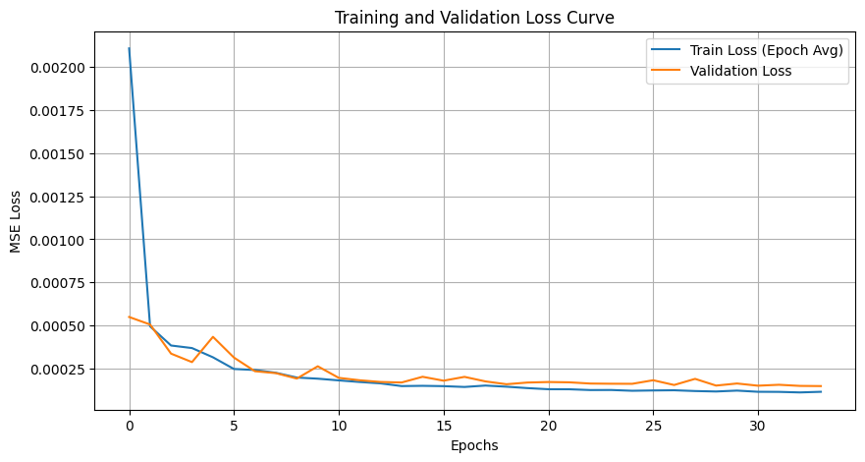

### **M10** | Tailored UNet18 fine-tuned with M6, trained and tested on ```MAR``` dataset with ```optuna``` optimizing learning rate with cosine scheduler

We wanted to compare differet regularization methods to help improve the model's preformence on the test set.

In this section we used a cosine scheduler. The cosine scheduler will help us get smoother losses since the cosine scheduler decays the learning rate slowly until we reach 0 learning rates. In addition, the scheduler adds implicit regularization and may help us generalize for the test set.

For M10 we also used the same optimal ```Optuna``` learning rates as M9 as well as initializing the encoder's weights with ```MAYO``` weights training and testing on ```MAR```.

---
Training time: ~3 hours.

Here we show, for training + testing on MAR dataset :
1.   Net Performance on test set (8% taken equaly from every body data folder)
2.   Losses plots (validition was 5% taken equaly from every body data folder)

---

As one can see, the output images which are produced by the deep net,  **have somewhat better quality compared to the input images** (mainly in terms of RMSE and PSNR). It is noticable that the losses graph is very smooth in the right side where the learning rate goes to 0, compared to the other models where the losses are more "jumpy". Although smoother loss, this model seems to preforme worse than perivious models with no scheduler. This might be due to the fact there aren't many epochs so the model doesn't get to learn much before the learning rates drop.

---
Source code from: ```Tailored_UNet18_MAR_M7_to_M11.ipynb``` (using train_fine_tune mode with M6 saved model from 4000 iterations, and cosine scheduler).

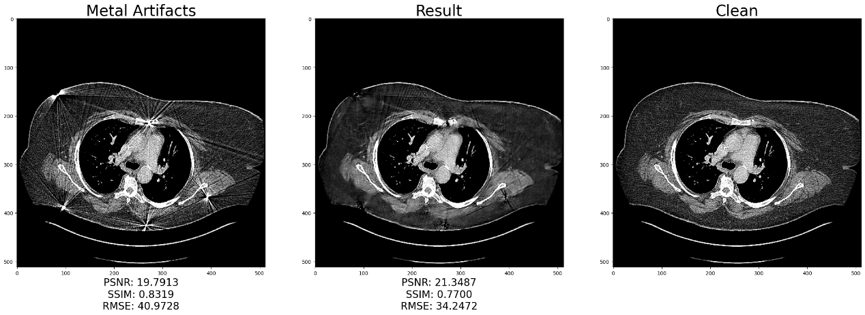

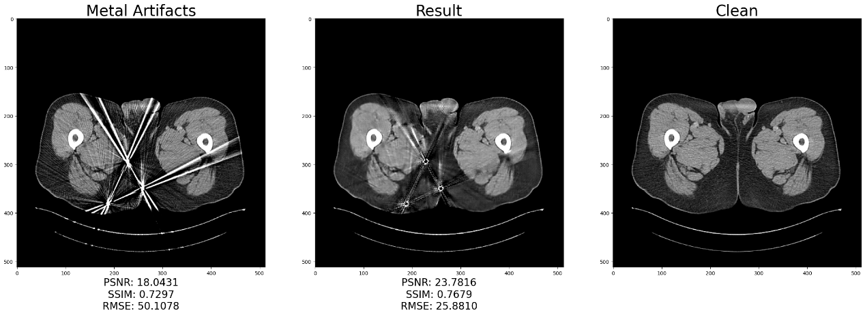

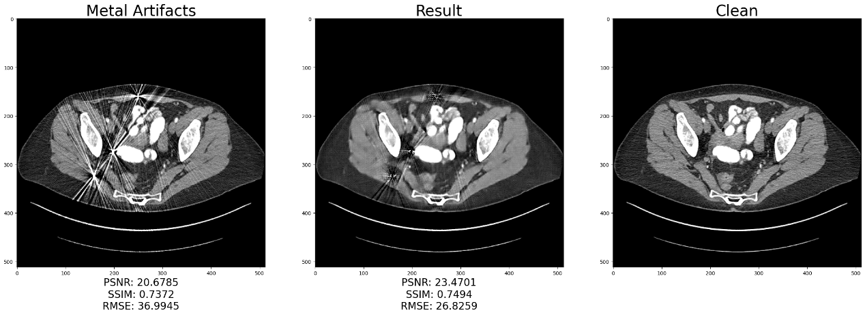

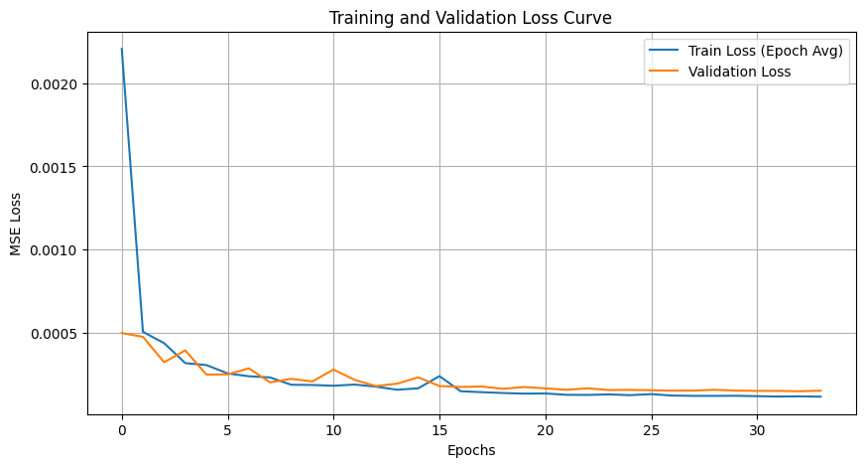

### **M11** | Tailored UNet18 fine-tuned with M6, trained and tested on ```MAR``` dataset with optuna optimizing learning rate with augmentation.

For our last model we used Explicit Regularization - Augmentation, in order to improve our model's generalization and preformence on the test set.

For M11 we also used the same optimal ```Optuna``` learning rates as M9 as well as initializing the encoder's weights with ```MAYO``` weights training and testing on ```MAR```.

---
Training time: ~3 hours.

Here we show, for training + testing on MAR dataset :
1.   Net Performance on test set (8% taken equaly from every body data folder)
2.   Losses plots (validition was 5% taken equaly from every body data folder)

---

As one can see, the output images which are produced by the deep net,  **have better quality compared to the input images** (mainly in terms of RMSE and PSNR and somtimes for SSIM). This models losses graph is more noisy than M10 and M9 - probably due to the "noisy" data which is the augmentation.

---
Source code from: ```Tailored_UNet18_MAR_M7_to_M11.ipynb``` (using train_fine_tune mode with M6 saved model from 4000 iterations, and augmentation).

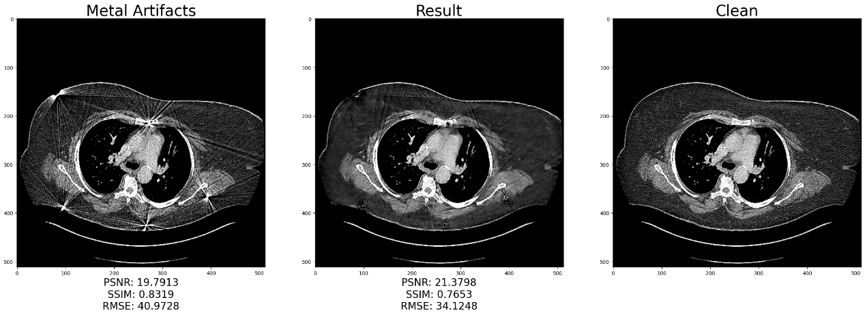

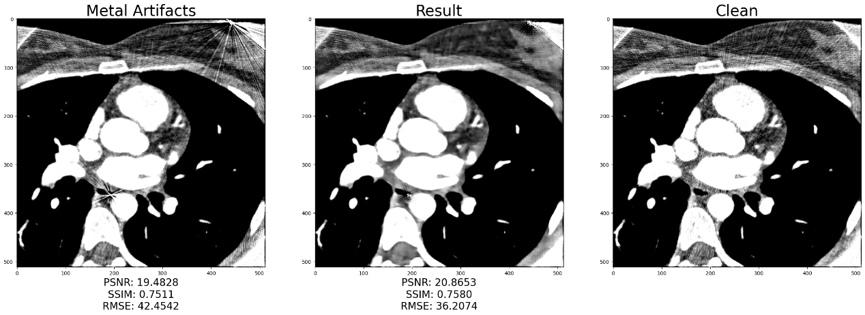

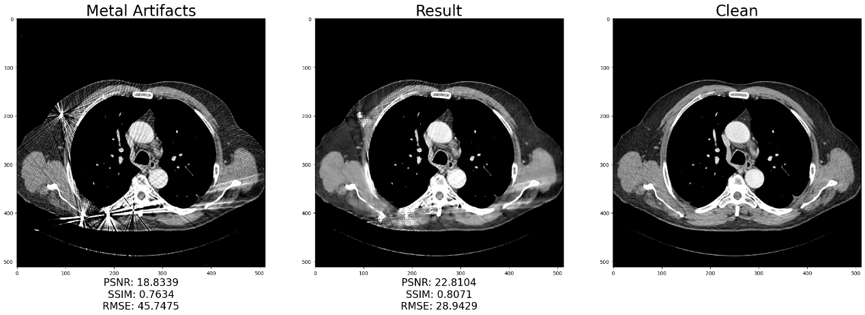

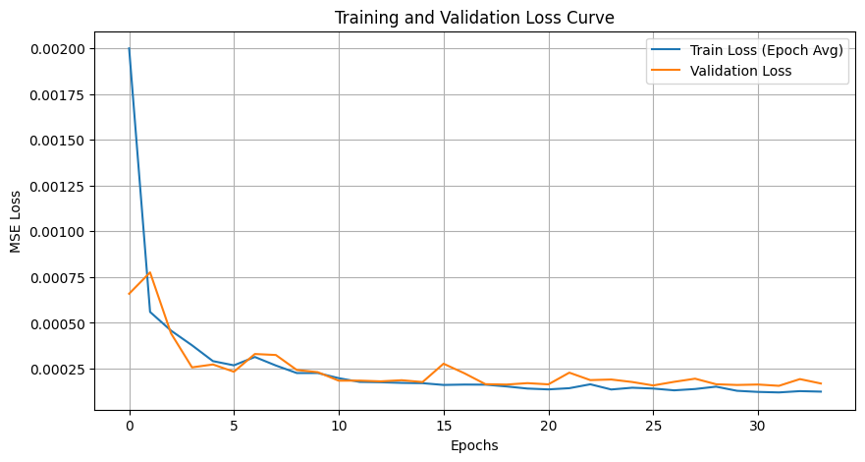

### **Summary** - Results and Conclusions Concerning the Performance of UNet18 implementation on ```MAYO``` and ```MAR``` dataset

At last, we shall compare the different models on the different datasets.
A we found a proper way to compare between the different methods is considering the average delta between the input (QD in Mayo, image with metal artifacts in MAR) and the net output in 3 different common mesurments for images comparation: RMSE, PSNR and SSIM. The measurments are taken in refer to the ground-truth (clean images).

Since the delta of measure M is: M(net) - M(in), the interperation should be:
*   higher, positive delta PSNR is better.
*   higher, positive delta SSIM is better.
*   lower, negative delta RMSE is better.

The averaged results on MAYO test set are as follows:

| Model | Model creating method | Avg delta PSNR | Avg delta SSIM | Avg delta RMSE |
|------|----------|------|-------|------:|
| M5 | randomly initilized weights |-11.8491 | -0.1897 | 39.9377 |
| M6 | Fine-tuned encoder on ImageNet | 0.6731 | -0.0144 | -1.3644 |

Yet, the model preformed was better on the MAR test set:

| Part | Model creating method | Avg delta PSNR | Avg delta SSIM | Avg delta RMSE |
|------|----------|------|-------|------:|
| M6| Only tested on the test set, fine-tuned encoder on ImageNet trained on MAYO |0.4088	| **-0.0001** |	-1.6537 |
| M7 | Fine-tuned encoder on ImageNet | 1.9416 | -0.0145 | -6.9438 |
| M8 | MAYO trained model | 2.153 | -0.0108 | **-7.6711** |
| M9 | MAYO trained model Optuna learning rates | 1.9772 | -0.0148 | -7.1259 |
| M10 | MAYO trained model Optuna learning rates and cosine scheduler |2.0446	|-0.0129 | -7.3356 |
| M11 | MAYO trained model Optuna learning rates, cosine scheduler and augmentations | **2.1779** | -0.0109 | -7.6543 |



---
Conclusion
---
* All of UNet18 measurments results were better for the ```MAR```  dataset
than the ```MAYO```  dataset, even for the excat same methods exhibit in M6 and M7.

* There is no one model which receives all the best measurements. The best model in terms of PSNR is M11, which also received good visual results. The best model in terms of SSIM is M6 tested on MAR, although the visual results are the worst of all model, M6 did the least visual changes so the SSIM did not change much. The best model in terms of MSE is M8 which also received good visual results.

* Augmentation better in all preformence mesurements compared to the cosine scheduler. This is also may due to the fact there weren't many epochs so the model didn't get to learn much before the learning rates dropped.

* More conclusions can be seen in the project's report.